### Шаг 2. Исследовательский анализ

Цель данного этапа — выявить взаимосвязи между признаками и возможные закономерности.

#### 2.0 Загрузка данных 

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
print("Setup complete!")

Setup complete!


In [3]:
data_2015 = pd.read_csv('../data/2015.csv')
data_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


#### 2.1 Корреляционная матрица

Для оценки линейных связей между числовыми признаками была рассчитана корреляционная матрица.

<Axes: >

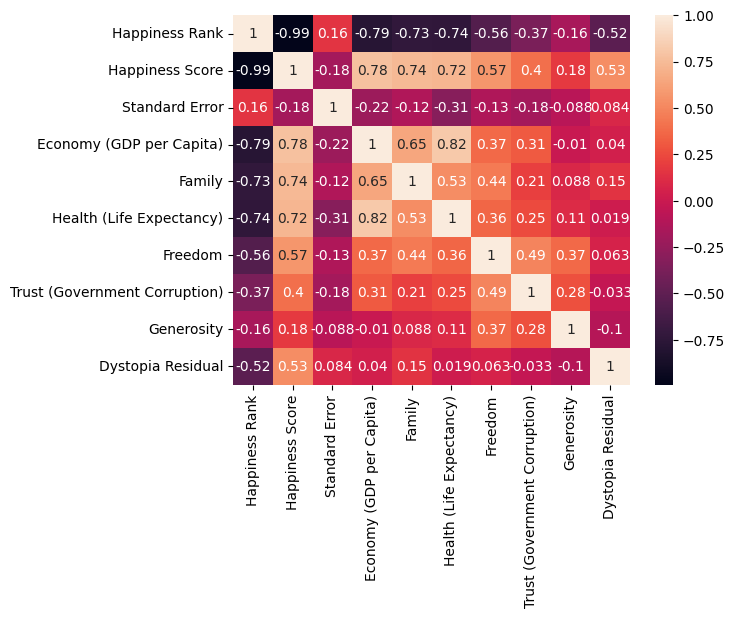

In [7]:
data_without_obj = data_2015.drop(columns=['Country', 'Region'])
correlation_matrix = data_without_obj.corr()
sns.heatmap(data=correlation_matrix, annot=True)

Обнаружена сильная положительная корреляция между ВВП на душу населения (Economy (GDP per Capita)) и уровнем счастья (Happiness Score) и ВВП на душу населения (Economy (GDP per Capita)) и продолжительностью жизни населения (Health (Life Expectancy)), а также сильная отрицательная между показателем щедрости (Generosity) и ВВП на душу населения (Economy (GDP per Capita)). 

Ниже рассмотрена корреляционная матрица относительно уровня счастья (Happiness Score). 

<Axes: >

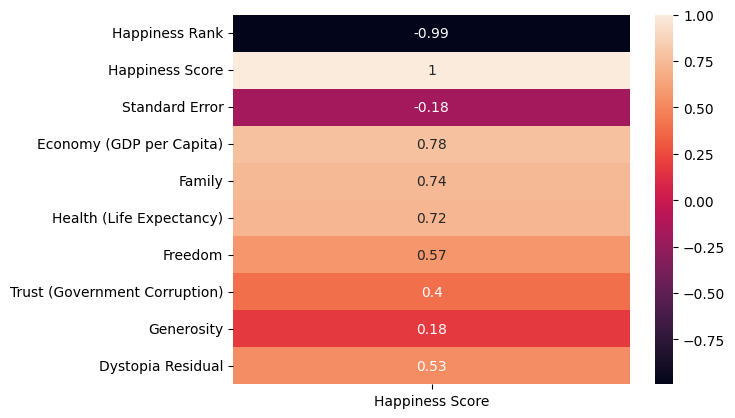

In [11]:
data_without_obj = data_2015.drop(columns=['Country', 'Region'])
correlation_matrix = data_without_obj.corr()[['Happiness Score']]
sns.heatmap(data=correlation_matrix, annot=True)

Сильная положительная корреляция наблюдается между уровнем счастья (Happiness Score) и ВВП на душу населения (Economy (GDP per Capita)), между уровнем счастья (Happiness Score) и показателем социальной поддержки (Family), а также между уровнем счастья (Happiness Score) и продолжительностью жизни населения (Health (Life Expectancy)). 

#### 2.2 Построение диаграмм для пар показателей

Для наиболее значимых пар признаков были построены диаграммы разброса.

<Axes: xlabel='Economy (GDP per Capita)', ylabel='Happiness Score'>

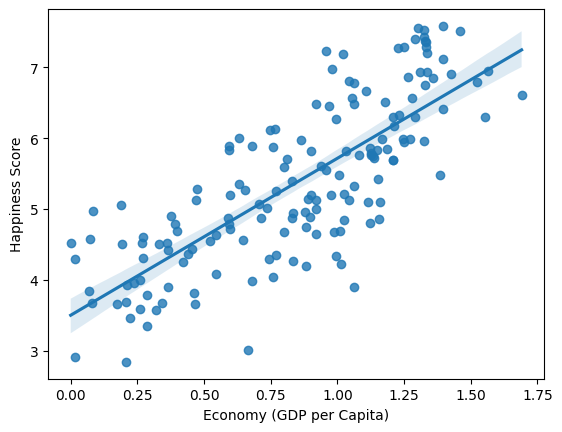

In [14]:
sns.regplot(x=data_2015['Economy (GDP per Capita)'], y=data_2015['Happiness Score'])

Признаки: уровень счастья (Happiness Score) и ВВП на душу населения (Economy (GDP per Capita)). Заметна положительная зависимость - при увеличении ВВП на душу населения уровень счастья растет. Распределение значений равномерное. Гипотеза о влиянии ВВП государства на субъективное восприятие счастья человеком подтверждена. 

<Axes: xlabel='Health (Life Expectancy)', ylabel='Happiness Score'>

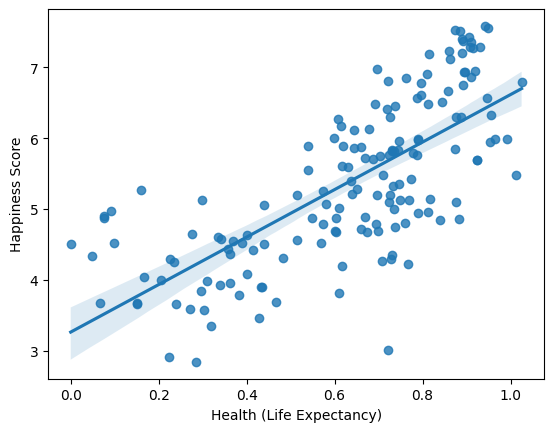

In [16]:
sns.regplot(x=data_2015['Health (Life Expectancy)'], y=data_2015['Happiness Score'])

Признаки: уровень счастья (Happiness Score) и продолжительность жизни населения (Health (Life Expectancy)). Наблюдается положительная зависимость между признаками, но на диаграмме также присутствуют выбросы. Но несмотря на их наличие, общий тренд остаётся положительным, что согласуется с результатами корреляционного анализа.

<Axes: xlabel='Family', ylabel='Happiness Score'>

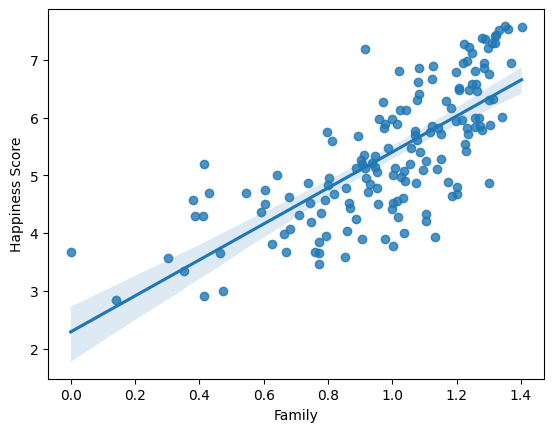

In [5]:
sns.regplot(x=data_2015['Family'], y=data_2015['Happiness Score'])

Признаки: уровень счастья (Happiness Score) и социальная поддержка (Family). Между этими признаками есть положительная зависимость, однако значения в основном сосредоточены в правой части диаграммы. То есть в среднем уровень социальной поддрежки достаточно высок, так как наблюдается рост числа значений, начиная с середины шкалы деления. Гипотеза о влиянии социальной поддержки на уровень счастья подтверждена. 

<Axes: xlabel='Economy (GDP per Capita)', ylabel='Generosity'>

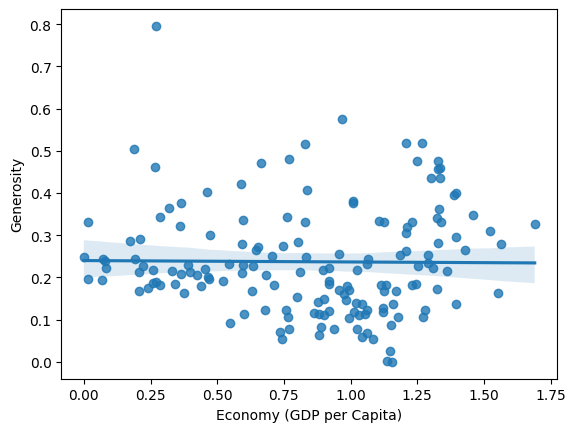

In [8]:
sns.regplot(x=data_2015['Economy (GDP per Capita)'], y=data_2015['Generosity'])

Признаки: уровень щедрости в стране (Generosity) и ВВП на душу населения (Economy (GDP per Capita)). Диаграмма демонстрирует практически горизонтальное распределение точек, при увеличении значений ВВП на душу населения уровень щедрости не склонен к росту. Ссылаясь на корреляционную матрицу, стоит отметить, что корреляция между щедростью и ВВП отрицательная, однако визуально зависимость выражена слабо, что может указывать на отсутствие линейной связи и влияние других факторов. Гипотеза не подтверждена: уровень ВВП не определяет щедрость людей.

<Axes: xlabel='Economy (GDP per Capita)', ylabel='Health (Life Expectancy)'>

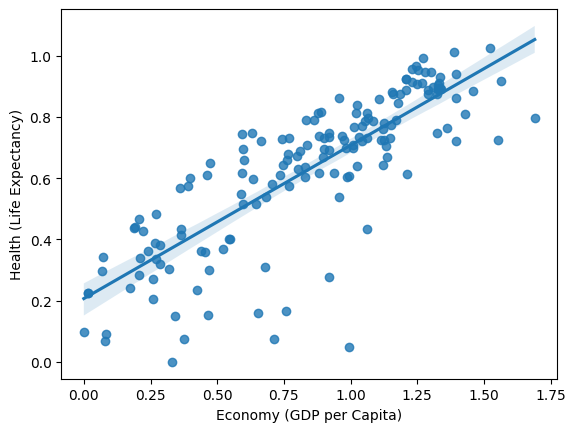

In [23]:
sns.regplot(x=data_2015['Economy (GDP per Capita)'], y=data_2015['Health (Life Expectancy)'])

Признаки: продолжительность жизни населения (Health (Life Expectancy)) и ВВП на душу населения (Economy (GDP per Capita)). Между этой парой признаков присутствует положительная зависимость. Гипотеза подтверждена: ВВП на душу населения в стране влияет на продолжительность жизни в этой стране.    

### Вывод

При исследовании датасета были обнаружены следующие закономерности: значительное влияние на уровень счастья влияют ВВП на душу населения, продолжительность жизни населения в стране и социальная поддержка. Высокие показатели этих трех признаков в стране ассоциированы с более высоким уровнем счастья людей, проживающих в этой стране. Также, вероятно, чем выше уровень ВВП на душу населения, тем дольше живут люди в этой стране. Однако, с ростом ВВП в стране, уровень щедрости (доля населения, совершающая благотворительные пожертвования, и характеризующая склонность к финансовой помощи другим) падает.